# Triangular Fuzzification of `Polymer MW` and `Particle Size`

**The two features**
- **Polymer MW** — molecular weight of the PLGA polymer (kDa).
- **Particle Size** — the microparticle diameter (µm).


In [6]:
!pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]


In [7]:
# --- Setup -------------------------------------------------------------------
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Reuse the PROJECT'S OWN fuzzy code so this notebook matches the methodology.
sys.path.insert(0, os.path.abspath("."))
from fuzzypharma.fuzzy import FuzzyFeaturizer, triangular_memberships

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})

# Consistent, colorblind-friendly colors for the three linguistic sets.
SET_COLORS = {"Low": "#4C78A8", "Medium": "#F58518", "High": "#54A24B"}
FEATURES = ["Polymer MW", "Particle Size"]
UNITS = {"Polymer MW": "kDa", "Particle Size": "µm"}
print("Setup OK — using fuzzypharma.fuzzy.FuzzyFeaturizer")


Setup OK — using fuzzypharma.fuzzy.FuzzyFeaturizer


In [8]:
# --- Load data ---------------------------------------------------------------
raw = pd.read_excel("mp_dataset_processed.xlsx", sheet_name="Sheet1")
print("Raw workbook:", raw.shape, "rows x cols")

# Each formulation appears once PER TIME POINT of its release curve, so the static
# features repeat. To describe the TWO features fairly we keep one row per formulation.
df = raw.drop_duplicates("Formulation Index")[["Formulation Index"] + FEATURES].reset_index(drop=True)
print("Unique formulations used for analysis:", len(df))
df[FEATURES].describe().round(3)


Raw workbook: (4913, 13) rows x cols
Unique formulations used for analysis: 321


,Polymer MW,Particle Size
count,321.000,321.000
mean,37.072,46.043
std,29.089,46.456
min,2.300,1.153
25%,12.000,16.730
50%,31.000,35.000
75%,46.000,59.900
max,215.000,295.700


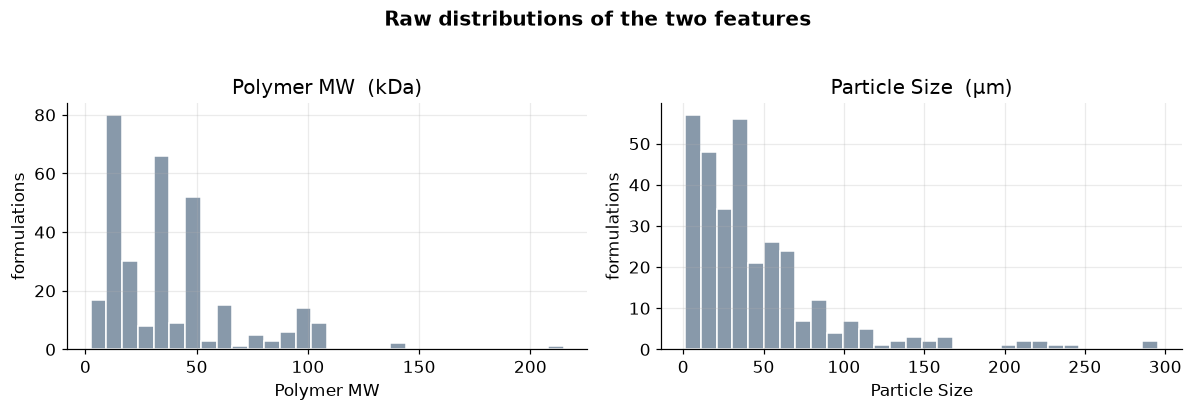

In [9]:
# Quick look at the two distributions (raw values, before fuzzification)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, col in zip(axes, FEATURES):
    ax.hist(df[col], bins=30, color="#8899AA", edgecolor="white")
    ax.set_title(f"{col}  ({UNITS[col]})")
    ax.set_xlabel(col); ax.set_ylabel("formulations")
fig.suptitle("Raw distributions of the two features", y=1.03, fontweight="bold")
plt.tight_layout(); plt.show()


## 2. Fit the knots (Low / Medium / High centres)

We fit the project's `FuzzyFeaturizer` with:
- `n_sets=3` → **Low, Medium, High**
- `membership="triangular"`
- `knot_strategy="quantile"` → the three knots are the **25th / 50th / 75th percentiles**.

Fitting here just *computes those three numbers per feature*. The `.report()` method
prints exactly what was learned — this is the whole "training" of fuzzification.


In [10]:
fuz = FuzzyFeaturizer(n_sets=3, membership="triangular",
                      knot_strategy="quantile", features=FEATURES)
fuz.fit(df[FEATURES])

report = fuz.report()
report


,feature,fuzzifiable,knot source,knots,note
0,Polymer MW,True,quantile,"[12.0, 31.0, 46.0]",knots from raw quantiles
1,Particle Size,True,quantile,"[16.73, 35.0, 59.9]",knots from raw quantiles


In [11]:
# Pull the fitted knots out for plotting / explanation
KNOTS = {f: fuz.knots_[f].knots for f in FEATURES}
for f in FEATURES:
    lo, mid, hi = KNOTS[f]
    print(f"{f:>14}:  Low peak={lo:.2f}   Medium peak={mid:.2f}   High peak={hi:.2f}  ({UNITS[f]})")


    Polymer MW:  Low peak=12.00   Medium peak=31.00   High peak=46.00  (kDa)
 Particle Size:  Low peak=16.73   Medium peak=35.00   High peak=59.90  (µm)


## 3. Visualise the triangular membership functions

Each panel shows the three membership curves for one feature. Read them like this:
- Where the **blue (Low)** line is high, values are strongly "Low".
- The lines **cross at membership 0.5** — those crossing points are the natural
  soft boundaries between neighbouring sets.
- The grey histogram behind shows where the real formulations actually sit.


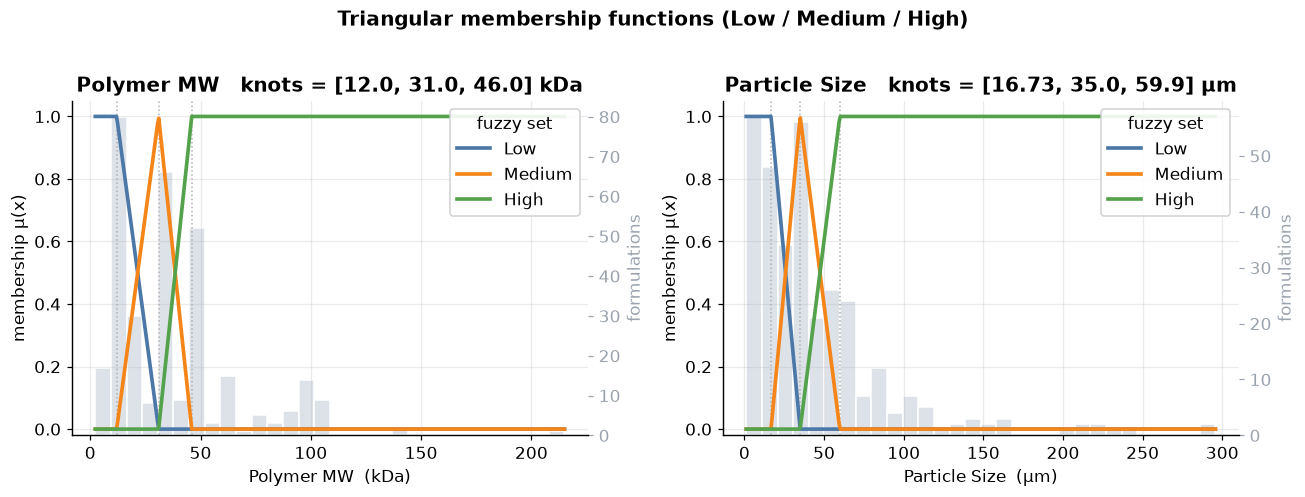

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, col in zip(axes, FEATURES):
    knots = KNOTS[col]
    xs = np.linspace(df[col].min(), df[col].max(), 400)
    mem = triangular_memberships(xs, knots)          # shape (400, 3)

    # histogram of real data on a secondary axis (context)
    ax2 = ax.twinx()
    ax2.hist(df[col], bins=30, color="#DDE2E8", edgecolor="white", zorder=0)
    ax2.set_ylabel("formulations", color="#99A2AD"); ax2.grid(False)
    ax2.tick_params(axis="y", colors="#99A2AD")

    for j, label in enumerate(fuz.labels_):
        ax.plot(xs, mem[:, j], color=SET_COLORS[label], lw=2.4, label=label, zorder=3)
    for k in knots:  # mark the knot positions
        ax.axvline(k, color="#B0B0B0", ls=":", lw=1, zorder=1)
    ax.set_zorder(ax2.get_zorder() + 1); ax.patch.set_visible(False)
    ax.set_ylim(-0.02, 1.05)
    ax.set_title(f"{col}   knots = {np.round(knots,2).tolist()} {UNITS[col]}", fontweight="bold")
    ax.set_xlabel(f"{col}  ({UNITS[col]})"); ax.set_ylabel("membership μ(x)")
    ax.legend(title="fuzzy set", loc="upper right", framealpha=0.9)
fig.suptitle("Triangular membership functions (Low / Medium / High)", y=1.02, fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()


## 4. Apply the fuzzification (transform)

`transform` turns each feature value into **three membership columns**. Below are a few
formulations with their crisp values and the resulting memberships. Notice the three
memberships of a feature always **sum to 1.0**.


In [13]:
fuzzy_cols = fuz.transform(df[FEATURES])
out = pd.concat([df[["Formulation Index"] + FEATURES], fuzzy_cols], axis=1)

# sanity check: memberships of each feature sum to 1
for col in FEATURES:
    s = fuzzy_cols[[f"{col} [{l}]" for l in fuz.labels_]].sum(axis=1)
    print(f"{col}: membership row-sums min={s.min():.4f} max={s.max():.4f} (should be 1.0)")

out.head(8).round(3)


Polymer MW: membership row-sums min=1.0000 max=1.0000 (should be 1.0)
Particle Size: membership row-sums min=1.0000 max=1.0000 (should be 1.0)


,Formulation Index,Polymer MW,Particle Size,Polymer MW [Low],Polymer MW [Medium],Polymer MW [High],Particle Size [Low],Particle Size [Medium],Particle Size [High]
0,1,75.0,47.723,0.0,0.0,1.0,0.000,0.489,0.511
1,2,12.0,1.800,1.0,0.0,0.0,1.000,0.000,0.000
2,3,12.0,12.500,1.0,0.0,0.0,1.000,0.000,0.000
3,4,12.0,29.300,1.0,0.0,0.0,0.312,0.688,0.000
4,5,12.0,58.000,1.0,0.0,0.0,0.000,0.076,0.924
5,6,31.0,1.500,0.0,1.0,0.0,1.000,0.000,0.000
6,7,31.0,12.900,0.0,1.0,0.0,1.000,0.000,0.000
7,8,31.0,34.800,0.0,1.0,0.0,0.011,0.989,0.000


In [14]:
# A hand-picked worked example: watch memberships change as a value grows
demo_vals = np.array([5, 12, 25, 34, 46, 120])   # Polymer MW examples (kDa)
demo = pd.DataFrame(triangular_memberships(demo_vals, KNOTS["Polymer MW"]),
                    columns=[f"Low", "Medium", "High"])
demo.insert(0, "Polymer MW (kDa)", demo_vals)
print("How Polymer MW memberships shift across the range:")
demo.round(3)


How Polymer MW memberships shift across the range:


,Polymer MW (kDa),Low,Medium,High
0,5,1.000,0.000,0.0
1,12,1.000,0.000,0.0
2,25,0.316,0.684,0.0
3,34,0.000,0.800,0.2
4,46,0.000,0.000,1.0
5,120,0.000,0.000,1.0


## 5. Which set does each formulation lean toward?

For a quick overview we can take the **dominant** set for each value (the set with the
highest membership). This is only for *understanding* — the model would use the full
graded memberships, not just the winner.


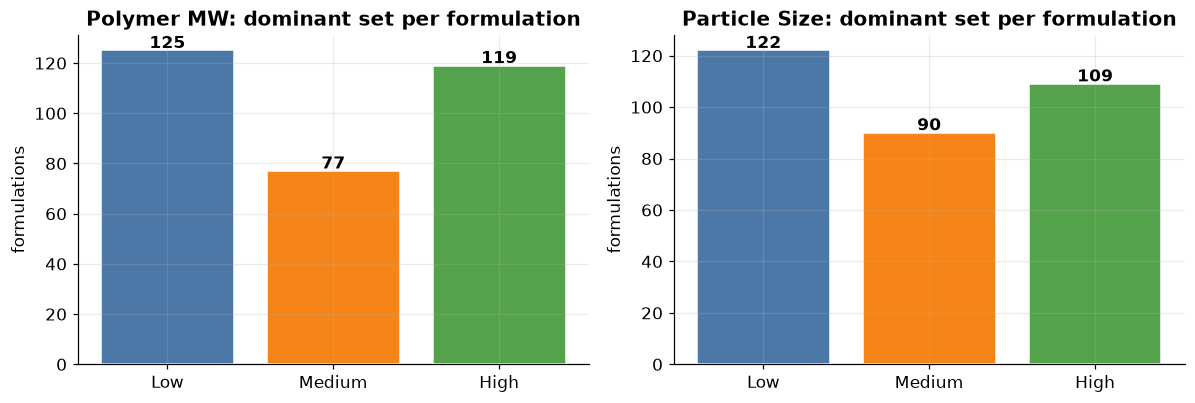

In [15]:
dominant = {}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, col in zip(axes, FEATURES):
    cols = [f"{col} [{l}]" for l in fuz.labels_]
    dom = fuzzy_cols[cols].idxmax(axis=1).str.extract(r"\[(\w+)\]")[0]
    dominant[col] = dom
    counts = dom.value_counts().reindex(fuz.labels_)
    ax.bar(counts.index, counts.values, color=[SET_COLORS[l] for l in counts.index],
           edgecolor="white")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1, str(int(v)), ha="center", fontweight="bold")
    ax.set_title(f"{col}: dominant set per formulation", fontweight="bold")
    ax.set_ylabel("formulations")
plt.tight_layout(); plt.show()


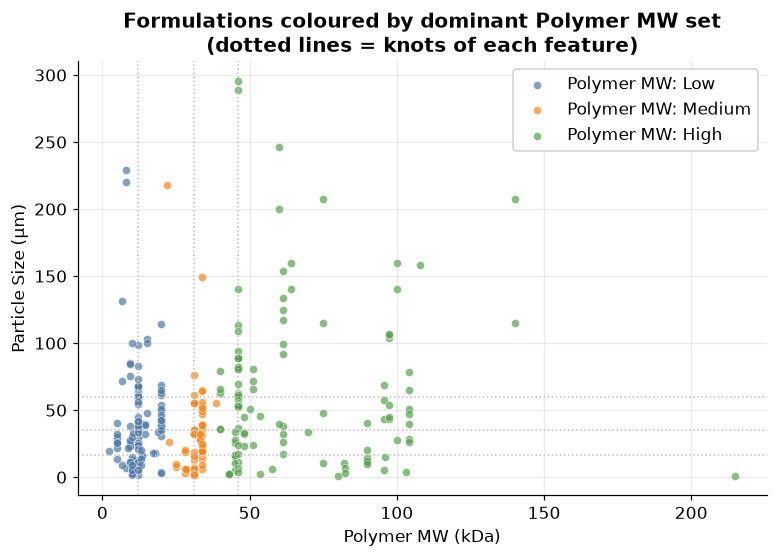

In [16]:
# Joint view: the two features together, coloured by Polymer MW's dominant set
fig, ax = plt.subplots(figsize=(7.2, 5.2))
for label in fuz.labels_:
    m = dominant["Polymer MW"] == label
    ax.scatter(df.loc[m, "Polymer MW"], df.loc[m, "Particle Size"],
               s=28, alpha=0.7, color=SET_COLORS[label], edgecolor="white",
               linewidth=0.4, label=f"Polymer MW: {label}")
for k in KNOTS["Polymer MW"]:
    ax.axvline(k, color="#C0C0C0", ls=":", lw=1)
for k in KNOTS["Particle Size"]:
    ax.axhline(k, color="#C0C0C0", ls=":", lw=1)
ax.set_xlabel("Polymer MW (kDa)"); ax.set_ylabel("Particle Size (µm)")
ax.set_title("Formulations coloured by dominant Polymer MW set\n(dotted lines = knots of each feature)",
             fontweight="bold")
ax.legend(framealpha=0.9); plt.tight_layout(); plt.show()


## 6. Reading the results

**Fitted knots (the Low/Medium/High centres)**

| Feature | Low peak | Medium peak | High peak | unit |
|---|---|---|---|---|
| Polymer MW | ~12 | ~31 | ~46 | kDa |
| Particle Size | ~17 | ~35 | ~60 | µm |

*(exact values are printed by `report()` above; they are the 25/50/75 percentiles.)*

**What the membership plots tell us**
- **Polymer MW** is fairly tight: Low and Medium knots (12 → 31) are close, so the "Low"
  and "Medium" triangles overlap a lot in the crowded 12–34 kDa region. A long right tail
  (up to 215 kDa) means everything beyond 46 kDa is fully **High** (shoulder saturates
  at 1).
- **Particle Size** is more spread out (17 → 35 → 60 µm), giving wider, more even
  triangles, and a heavy right tail up to ~296 µm that sits fully in **High**.

**What the transform gives us**
- Every formulation now has, per feature, three numbers in `[0,1]` that sum to 1 — e.g. a
  25 kDa polymer is partly Low and partly Medium rather than being forced into one bin.
- The worked example table shows the smooth hand-off: at the knot value the membership of
  that set is exactly 1.0; halfway between two knots the two neighbours are ~0.5 / ~0.5.

**Dominant-set counts** give a coarse summary of how many formulations lean Low / Medium /
High for each feature — useful for a slide, but the real value of fuzzification is the
*graded* memberships, which keep the information that lives *between* the bins.


In [17]:
for col in FEATURES:
    saturated = (fuzzy_cols[f"{col} [High]"] >= 0.999).sum()
    print(f"{col}: {saturated}/{len(df)} formulations fully saturated at High=1.0",
          f"(values ≥ {KNOTS[col][2]:.1f} {UNITS[col]}, max reaches {df[col].max():.1f})")

Polymer MW: 102/321 formulations fully saturated at High=1.0 (values ≥ 46.0 kDa, max reaches 215.0)
Particle Size: 81/321 formulations fully saturated at High=1.0 (values ≥ 59.9 µm, max reaches 295.7)


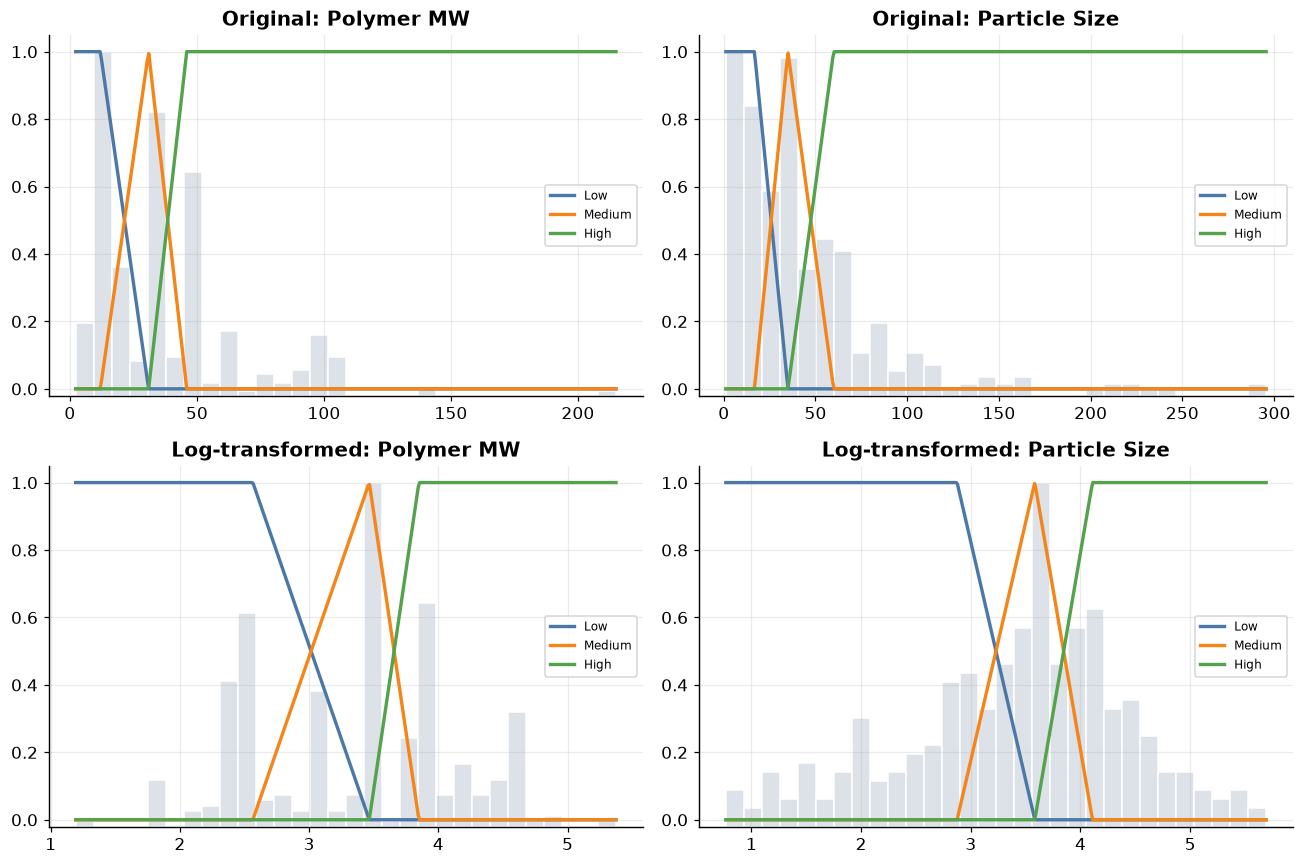

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for row, (transform, name) in enumerate([(lambda x: x, "Original"),
                                          (np.log1p, "Log-transformed")]):
    for ax, col in zip(axes[row], FEATURES):
        vals = transform(df[col])
        knots = np.quantile(vals, [0.25, 0.50, 0.75])   # نفس طريقتنا: quantile knots
        xs = np.linspace(vals.min(), vals.max(), 400)
        mem = triangular_memberships(xs, knots)
        ax2 = ax.twinx()
        ax2.hist(vals, bins=30, color="#DDE2E8", edgecolor="white", zorder=0)
        ax2.grid(False); ax2.set_yticks([])
        for j, label in enumerate(fuz.labels_):
            ax.plot(xs, mem[:, j], color=SET_COLORS[label], lw=2.2, label=label)
        ax.set_zorder(ax2.get_zorder()+1); ax.patch.set_visible(False)
        ax.set_title(f"{name}: {col}", fontweight="bold")
        ax.set_ylim(-0.02, 1.05); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()